# 🌦️ Weather Analysis — Interactive Walkthrough

This notebook demonstrates the **Weather Analysis App**: it pulls **live** weather from the free, key-less [Open-Meteo](https://open-meteo.com) API, analyses it, and draws charts inline.

If there is no internet connection it automatically falls back to a bundled data snapshot, so the notebook always runs end-to-end.

## 1. Setup
Import the project modules.

In [1]:
import os
import requests
from IPython.display import Image, display

from weather import analyzer, fetcher, geocoder, sample_data, visualizer
print('Modules loaded.')

Modules loaded.


## 2. Fetch live data
We resolve a city name to coordinates, then download current, hourly and daily data (with a week of recent history) plus air quality. On any failure we fall back to the offline sample.

In [2]:
CITY = 'London'
try:
    location = geocoder.geocode(CITY)
    data = fetcher.fetch_weather(location)
    print(f'Live data for {location.label}')
except (requests.RequestException, LookupError) as exc:
    print(f'Live fetch failed ({exc}); using bundled sample.')
    data = sample_data.load_sample()

print('Source:', data.source)
data.hourly.head()

Live data for London, United Kingdom
Source: live


,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,precipitation_probability,wind_speed_10m,wind_direction_10m
time,,,,,,,
2026-06-08 00:00:00,15.3,13.3,73,0.0,1,15.1,210
2026-06-08 01:00:00,15.0,13.0,76,0.0,4,15.5,210
2026-06-08 02:00:00,14.6,12.9,79,0.0,15,14.0,206
2026-06-08 03:00:00,14.4,12.9,80,0.0,31,12.2,204
2026-06-08 04:00:00,14.3,12.8,82,0.0,43,13.7,194


## 3. Current conditions & analysis
Compute summary statistics, a temperature trend and correlations.

In [3]:
analysis = analyzer.analyze(data)
summary = analysis.summary
for key in ['location', 'current_conditions', 'current_temperature', 'mean_temp',
            'min_temp', 'max_temp', 'total_precipitation', 'mean_daylight_hours',
            'max_us_aqi', 'aqi_category']:
    if key in summary:
        print(f'{key:22}: {summary[key]}')
print(f'\nTemperature trend     : {analysis.temp_trend_per_day:+.2f} °C/day')

location              : London, United Kingdom
current_conditions    : Overcast
current_temperature   : 23.4
mean_temp             : 18.6
min_temp              : 9.8
max_temp              : 28.9
total_precipitation   : 21.2
mean_daylight_hours   : 16.6
max_us_aqi            : 73.0
aqi_category          : Moderate

Temperature trend     : +0.92 °C/day


### Correlations between weather variables

In [4]:
analysis.correlations

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
temperature_2m,1.00,-0.67,-0.19,-0.00
relative_humidity_2m,-0.67,1.00,0.25,-0.18
precipitation,-0.19,0.25,1.00,-0.04
wind_speed_10m,-0.00,-0.18,-0.04,1.00


### Daily statistics

In [5]:
cols = [c for c in ['temperature_2m_max', 'temperature_2m_min', 'precipitation_sum']
        if c in analysis.daily_stats.columns]
analysis.daily_stats[cols]

,temperature_2m_max,temperature_2m_min,precipitation_sum
count,14.00,14.00,14.00
mean,22.77,14.88,1.52
std,4.49,3.55,2.58
min,16.30,9.80,0.00
25%,19.27,12.88,0.00
50%,22.90,14.95,0.42
75%,27.28,17.15,1.20
max,28.90,21.10,7.40


## 4. Charts
Render every chart and display it inline. (The app also saves these as PNGs and writes a Markdown report.)

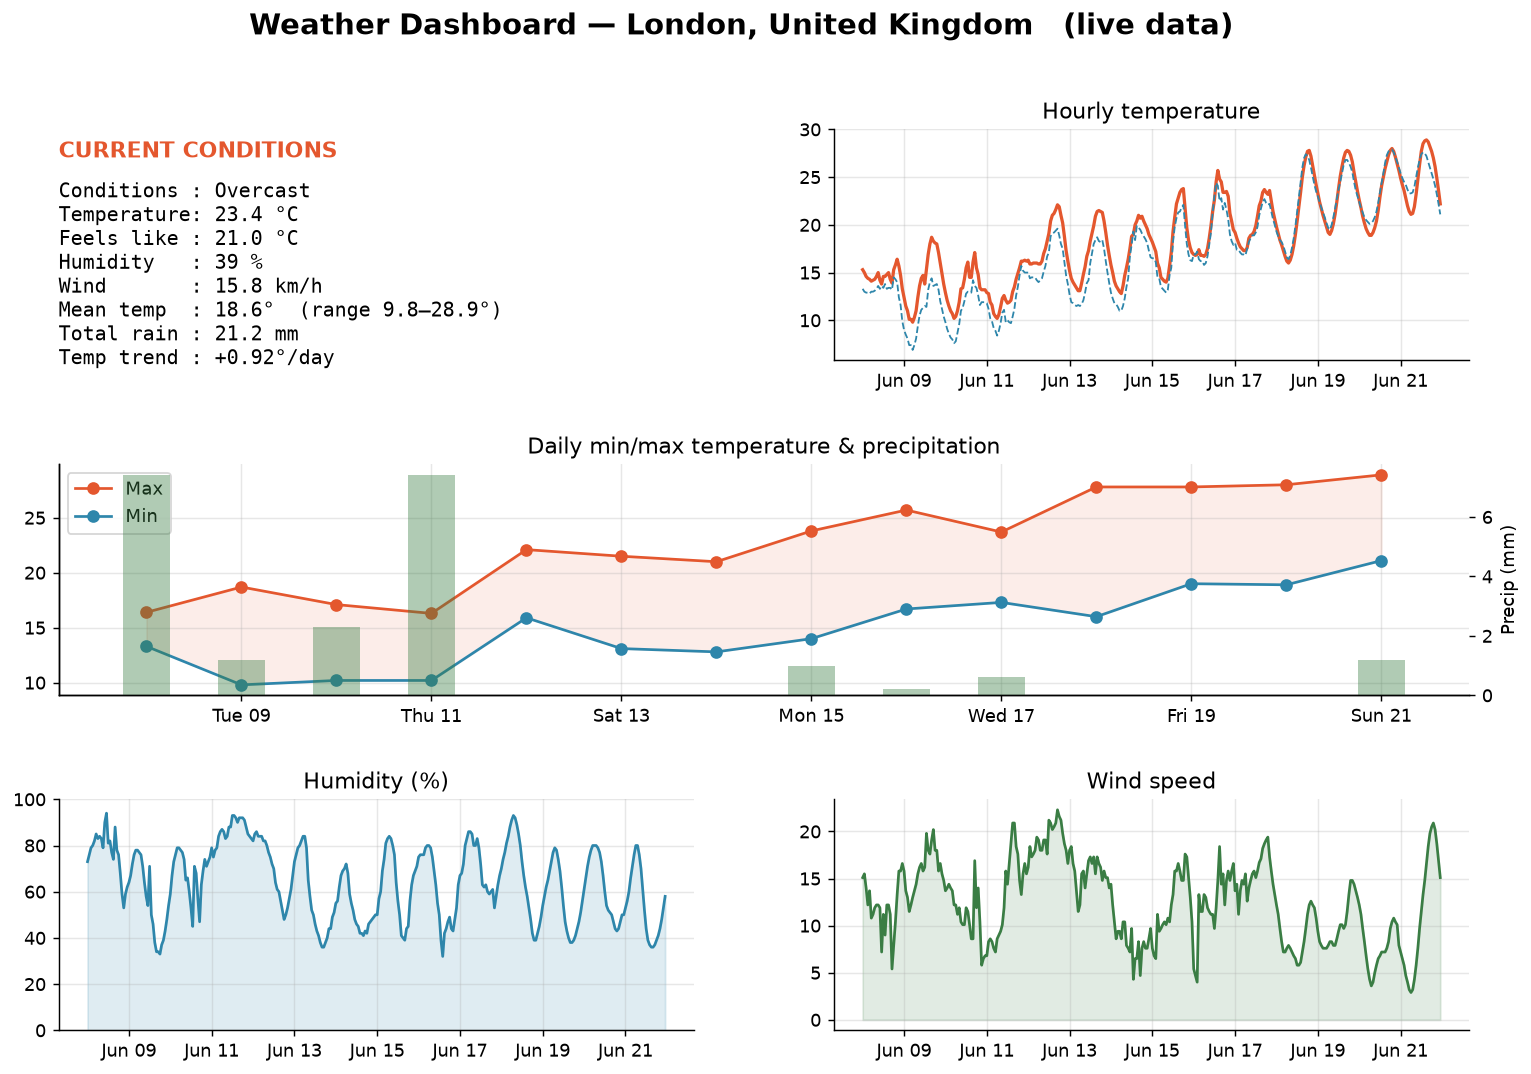

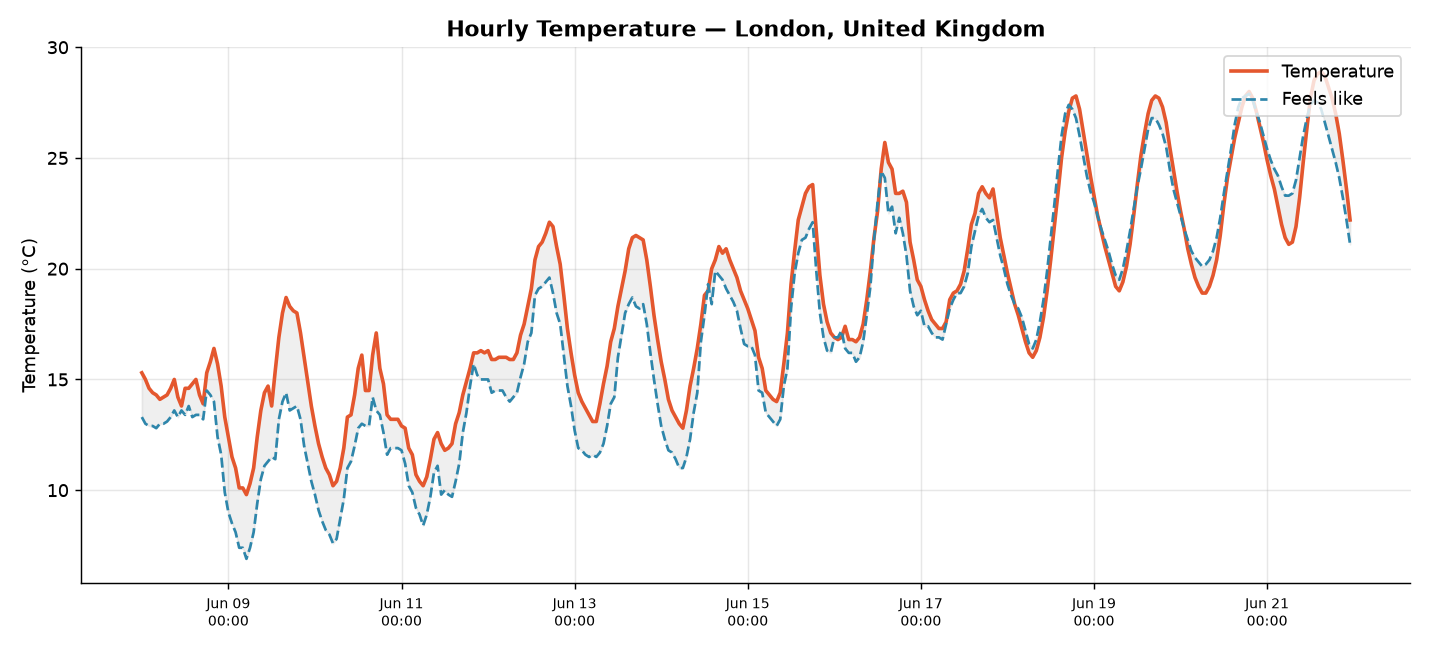

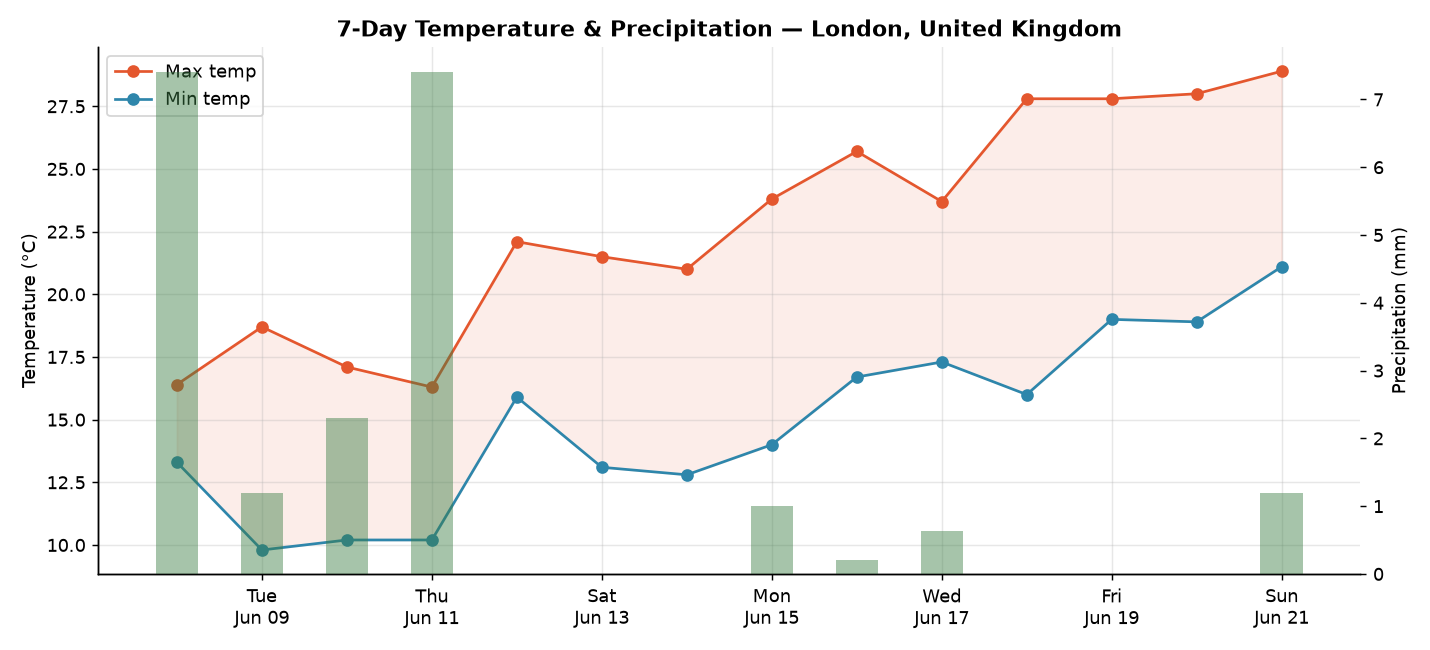

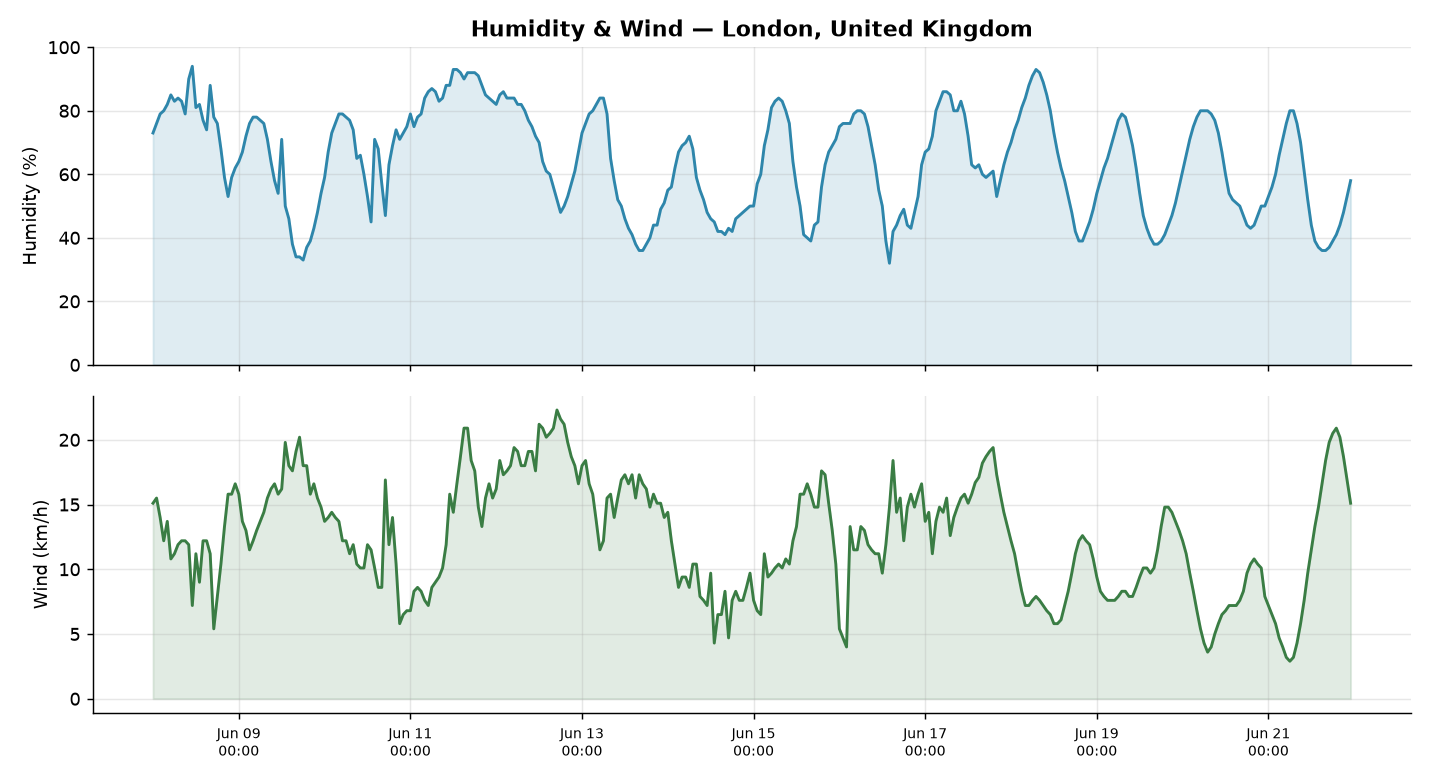

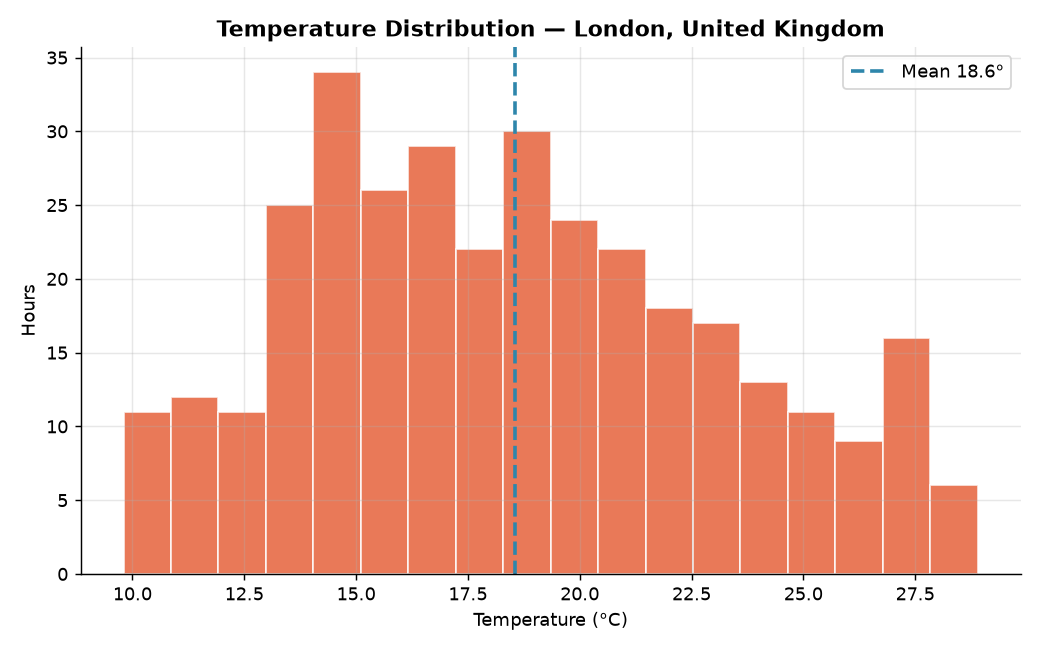

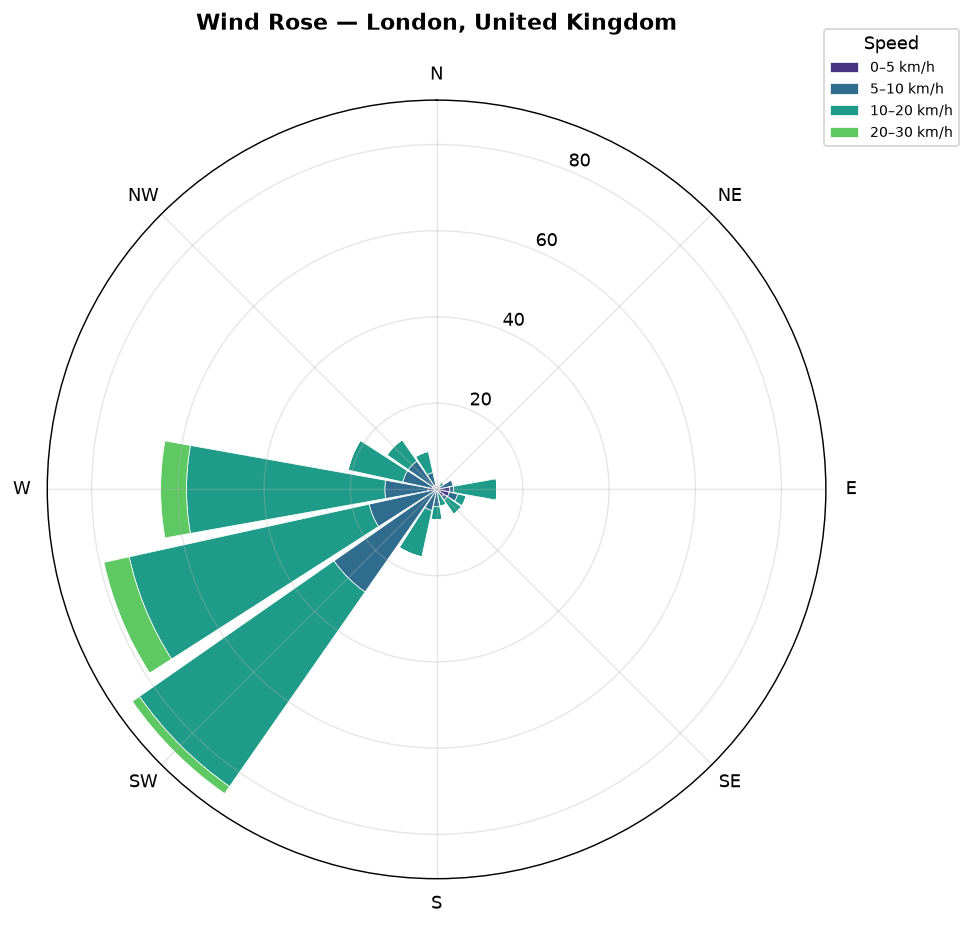

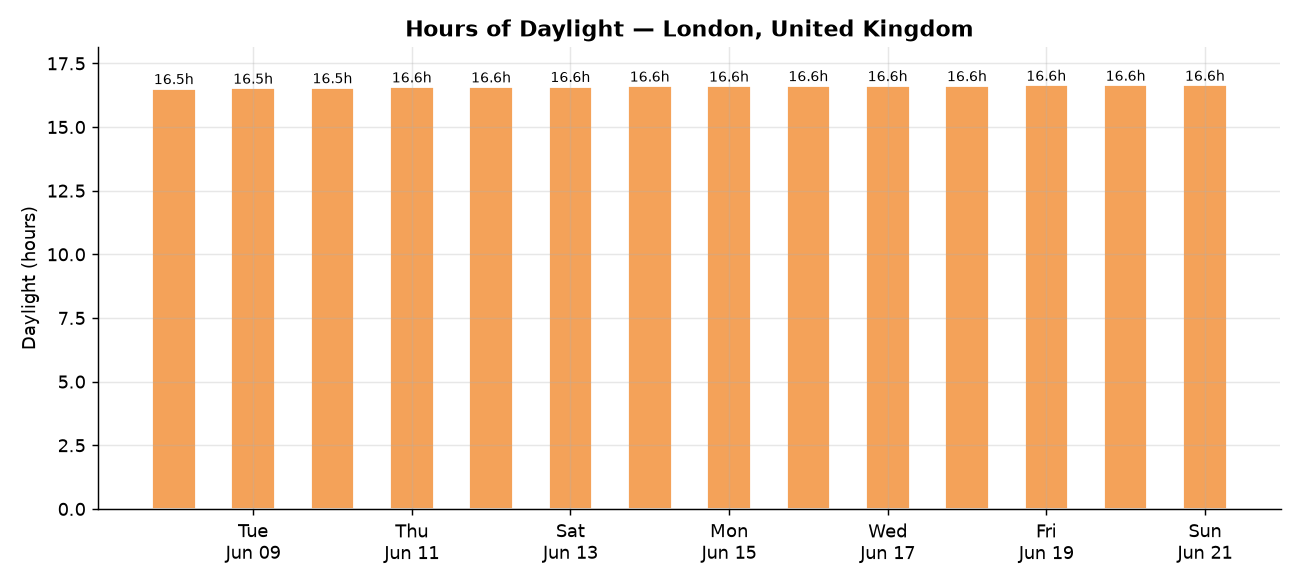

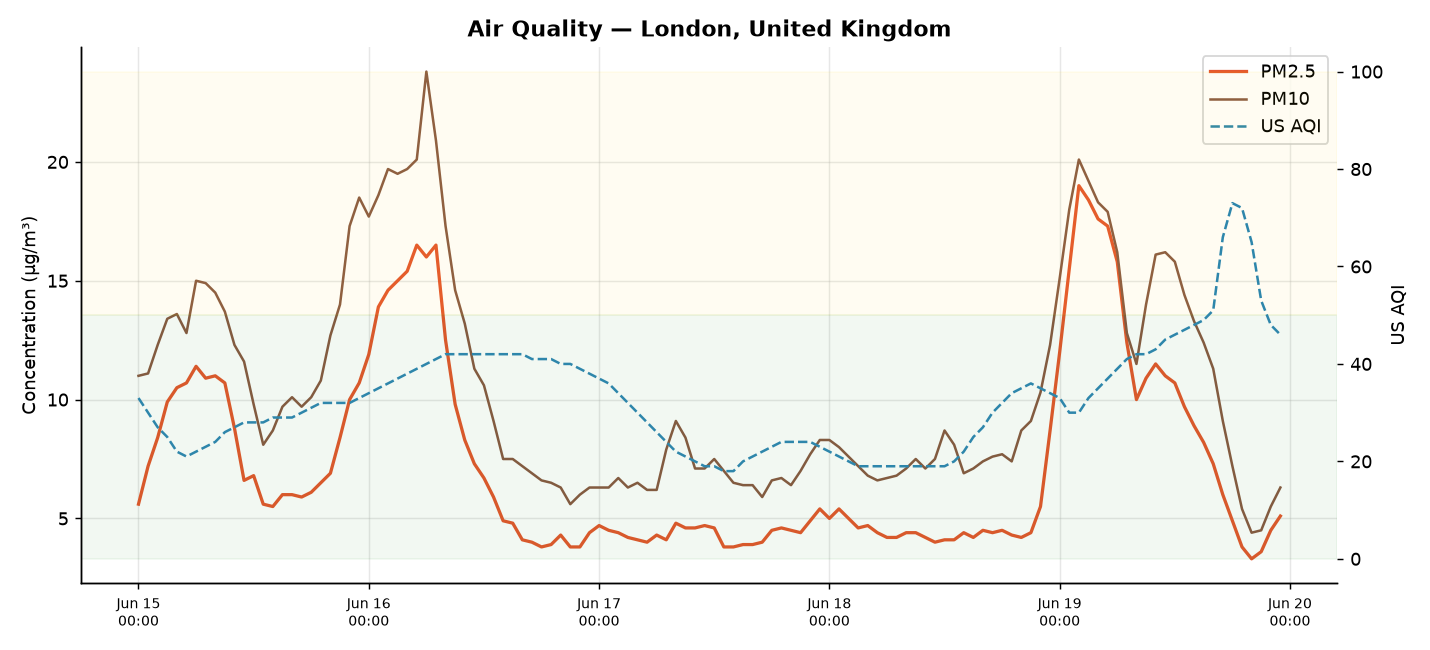

In [6]:
outdir = 'outputs'
charts = visualizer.render_all(data, analysis, outdir)
for path in charts:
    display(Image(filename=path))

## 5. Compare several cities
Overlay hourly temperature for a few cities and compare their mean / range.

London, United Kingdom       mean  18.6°C  range 9.8-28.9°C
Tokyo, Japan                 mean  21.3°C  range 15.5-29.1°C
Mumbai, India                mean  30.6°C  range 26.8-33.9°C


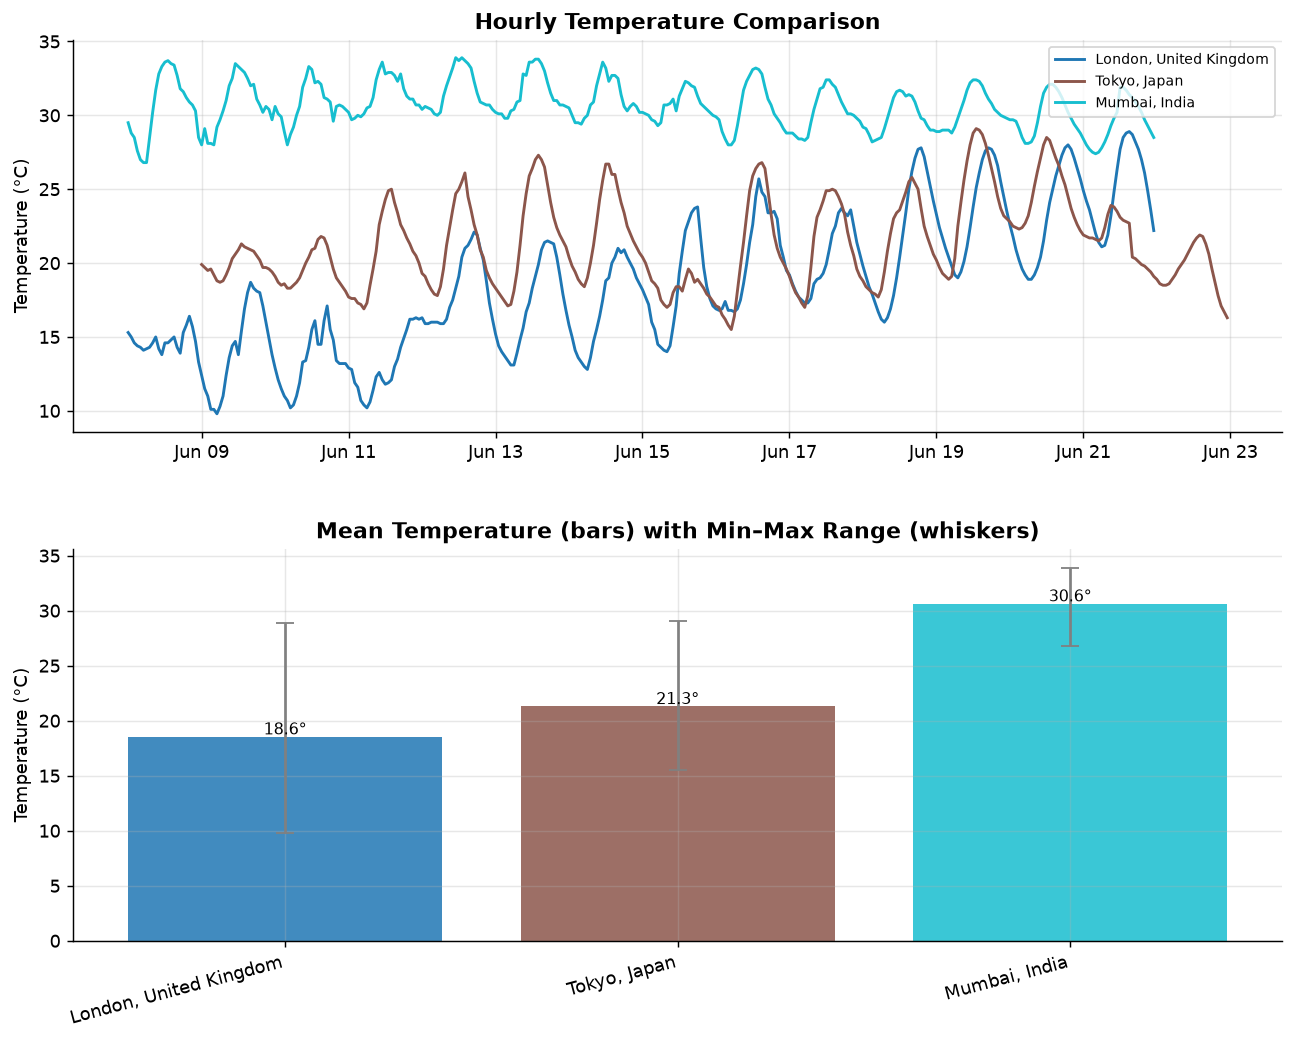

In [7]:
cities = ['London', 'Tokyo', 'Mumbai']
datasets = []
for c in cities:
    try:
        datasets.append(fetcher.fetch_weather(geocoder.geocode(c)))
    except (requests.RequestException, LookupError):
        pass
if len(datasets) < 2:
    datasets = [sample_data.load_sample()]

if len(datasets) >= 2:
    path = visualizer.plot_comparison(datasets, os.path.join('outputs', 'comparison.png'))
    for d in datasets:
        t = d.hourly['temperature_2m']
        print(f"{d.location.label:<28} mean {t.mean():5.1f}°C  range {t.min():.1f}-{t.max():.1f}°C")
    display(Image(filename=path))
else:
    print('Need at least two cities online to compare; skipped offline.')

## 6. Conclusion
From a single city name we fetched live data, derived statistics and trends, and produced a full set of visualisations — all reproducibly and offline-capable.

Run the command-line version with `python weather_app.py --city "Paris"` or the desktop GUI with `python weather_gui.py`.